In [18]:
file_path <- '/Users/kavinsomu/Documents/Georgia Tech/Fall 2024/CSE 6242/6242 Extract.csv'
data <- read.csv(file_path)

In [8]:
library(dplyr)
library(ggplot2)
library(MASS)
library(car)
library(rpart)
library(rpart.plot)
library(randomForest)
library(caret)
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ──────────────────────────────────────────────── tidyverse_conflicts() ──
✖ randomForest::combine() masks dplyr::combine()
✖ dplyr::filter()         masks stats::filter()
✖ dplyr::lag()            masks stats::lag()
✖ purrr::lift()           masks caret::lift()
✖ randomForest::margin()  masks ggplot2::margin()
✖ car::recode()           masks dplyr::recode()
✖ MASS::select()          masks dplyr::select()
✖ purrr::some()           masks car::some()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [19]:
head(data,5)

,USER_ID,ITM_ID,REFINED_PRODUCT_DESCRIPTION,MERCHANT_STANDARD_NAME,PRODUCT_BRAND,ORDER_ID,ORDER_DATE,ORDER_YEAR,ORDER_MONTH,ORDER_QUARTER,ORDER_TOTAL_AMOUNT,ORDER_TOTAL_QUANTITY,ITEM_PRICE,ITEM_QUANTITY,SALES_PER_ITEM,GOOGLE_TAXONOMY,USER_ZIP,USER_GENDER,USER_INCOME_CLASS,USER_AGE_BAND
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,229d53647469b0180b9cf391b78644978e9e3ddcd9f2c5b364f6fbfe85cd2726,1.18569e+19,"MEMBER'S MARK MESQUITE GRILLED CHICKEN BREAST, FROZEN (3 LBS.)",SAM'S CLUB,Sam's Club,9873e592a4bde8717d1a1cdf6dc6899a,45:27.0,2022,12,4,395.09,31,13.98,1,13.98,"FOOD, BEVERAGES & TOBACCO > MEAT & SEAFOOD > POULTRY > CHICKEN",79423,Female,100k-150k,45-54
2,974e8ce715d955ecc81f4b9fba8b07e64427aa43803b66dbbf2a9c60c6272345,6.88373e+18,"GREAT VALUE STRING LOW-MOISTURE PART-SKIM MOZZARELLA CHEESE, 12 COUNT, 12 OZ",WALMART,Walmart,4acc39c5ed738712f366d30c66c0a956,04:57.0,2021,7,3,44.05,15,2.84,1,2.84,"FOOD, BEVERAGES & TOBACCO > BEVERAGES > SPORTS DRINKS & MIXES > SPORTS DRINKS",13219,Female,50k-75k,65+
3,e3487aa4b61791ecc65aa56b4502716d9a1f9d7f25106fcbadef033fb3f4e660,1.17125e+19,TYSON 99% FAT FREE CHICKEN BREAST,INSTACART,Smith's,ddde8abe611e68501dc2e832bd5869e0,00:00.0,2021,5,2,395.75,50,2.99,7,20.93,"FOOD, BEVERAGES & TOBACCO > MEAT & SEAFOOD > POULTRY > CHICKEN",89104,Female,25k-50k,21-24
4,a50fda75f4a77ed7b3a84e30ee5223de1071b8ca8173f68c12188b389eb3958b,1.73193e+19,"STARBUCKS ICED ESPRESSO VANILLA LATTE ICED COFFEE DRINK, 40 OZ BOTTLE",WALMART,Walmart,5bbfa6ffca4cc65888291ff428def982,00:00.0,2024,10,4,NA,38,5.98,1,5.98,"FOOD, BEVERAGES & TOBACCO > BEVERAGES > COFFEE > COFFEE DRINKS",34233,Male,100k-150k,65+
5,66432abbd8614020297a55d76f29db5a47dfe404aa7c24ebf08521f2c43c7d65,1.45832e+18,BUTTERBALL OVEN ROASTED TURKEY BREAST,SHOP RITE,Shop Rite,861d283684dafa8abe8df14b197e12bc,18:42.0,2023,3,1,88.98,14,8.99,1,8.99,"FOOD, BEVERAGES & TOBACCO > MEAT & SEAFOOD > POULTRY > TURKEY",8107,Male,150k-200k,35-44


In [21]:
set.seed(42)

train_indices <- sample(1:nrow(data), size = 0.7 * nrow(data))

# Split the data
train_data <- data[train_indices, ]     # 70% for training
test_data <- data[-train_indices, ]     # Remaining 30% for testing

nrow(train_data) 
nrow(test_data)   

[1] 734002

[1] 314573

# Experiment 1

In [24]:
# Ensure there are no zero values in ITEM_PRICE or ITEM_QUANTITY to avoid issues with log transformation
df <- train_data %>% filter(ITEM_PRICE > 0 & ITEM_QUANTITY > 0)

# Create log-transformed columns for quantity and price
df <- df %>%
  mutate(log_quantity = log(ITEM_QUANTITY),
         log_price = log(ITEM_PRICE))

In [25]:
price_elasticity_model <- lm(log_quantity ~ log_price + USER_INCOME_CLASS, data = df)

cat("\n--- Price Elasticity Model Summary ---\n")
summary(price_elasticity_model)


--- Price Elasticity Model Summary ---



Call:
lm(formula = log_quantity ~ log_price + USER_INCOME_CLASS, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8614 -0.2322 -0.1592 -0.0368  5.6583 

Coefficients:
                             Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                 0.3877893  0.0021802  177.868  < 2e-16 ***
log_price                  -0.1200421  0.0006193 -193.825  < 2e-16 ***
USER_INCOME_CLASS0-25k     -0.0213069  0.0027198   -7.834 4.73e-15 ***
USER_INCOME_CLASS100k-150k -0.0137161  0.0022678   -6.048 1.47e-09 ***
USER_INCOME_CLASS150k-200k  0.0040167  0.0025850    1.554     0.12    
USER_INCOME_CLASS200k+      0.0277834  0.0024677   11.259  < 2e-16 ***
USER_INCOME_CLASS25k-50k   -0.0213217  0.0024254   -8.791  < 2e-16 ***
USER_INCOME_CLASS50k-75k   -0.0181968  0.0023321   -7.803 6.07e-15 ***
USER_INCOME_CLASS75k-100k  -0.0182570  0.0023417   -7.797 6.37e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4213 on 7

In [26]:
summary(df$ITEM_QUANTITY)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   1.421   1.000 400.000 

# Experiment 2

In [37]:
#Reset df
df <- train_data

In [28]:
df <- df %>% filter(ITEM_PRICE > 0 & ORDER_TOTAL_AMOUNT > 0)

df <- df %>% filter(!is.na(ORDER_TOTAL_AMOUNT))

df <- df %>% filter(ORDER_TOTAL_AMOUNT < quantile(ORDER_TOTAL_AMOUNT, 0.99))

In [29]:
summary(df$ORDER_TOTAL_AMOUNT)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.02   75.55  122.77  142.79  188.94  517.92 

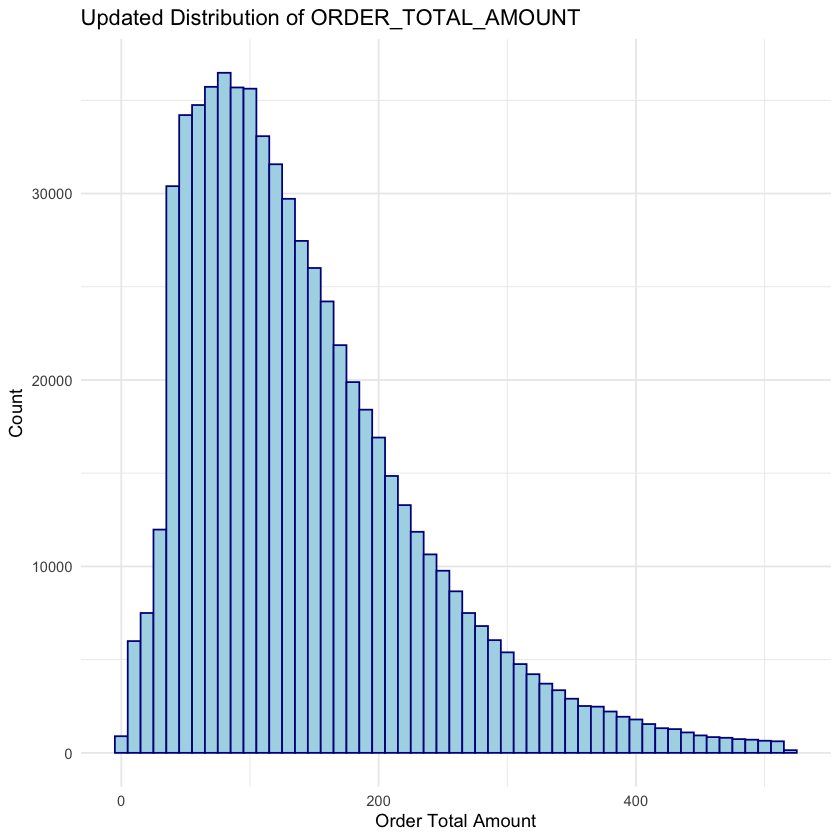

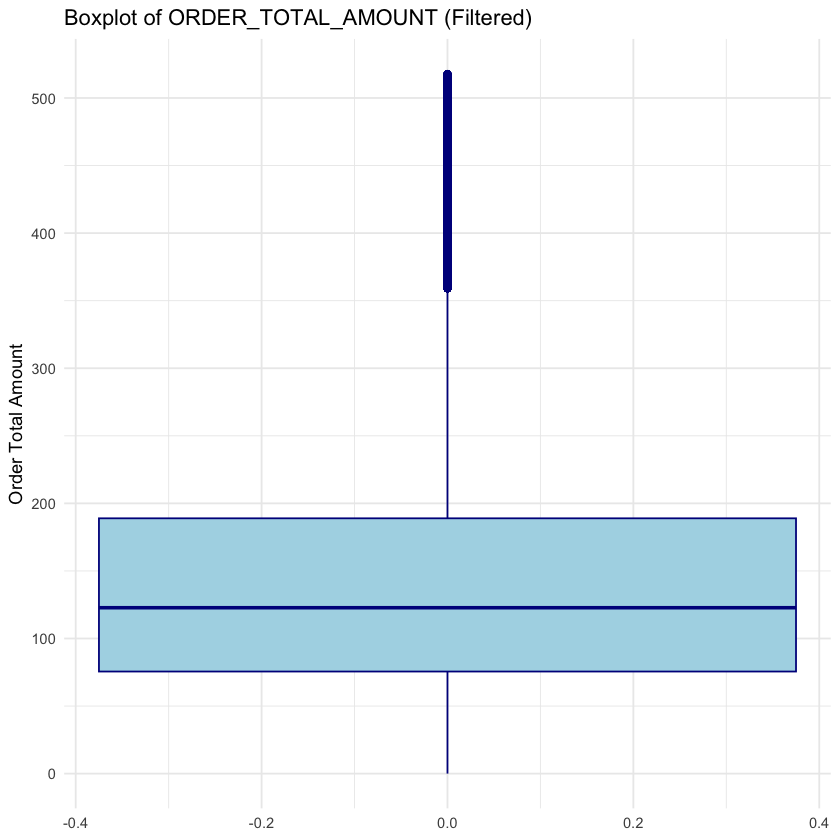

In [30]:
# Visualize the updated distribution
ggplot(df, aes(x = ORDER_TOTAL_AMOUNT)) +
  geom_histogram(binwidth = 10, fill = "lightblue", color = "darkblue") +
  labs(title = "Updated Distribution of ORDER_TOTAL_AMOUNT", x = "Order Total Amount", y = "Count") +
  theme_minimal()

# Boxplot
ggplot(df, aes(y = ORDER_TOTAL_AMOUNT)) +
  geom_boxplot(fill = "lightblue", color = "darkblue") +
  labs(title = "Boxplot of ORDER_TOTAL_AMOUNT (Filtered)", y = "Order Total Amount") +
  theme_minimal()

In [33]:
price_elasticity_model_2 <- lm(ORDER_TOTAL_AMOUNT~ ITEM_PRICE + USER_INCOME_CLASS + ORDER_YEAR + 
                                  ORDER_MONTH + ORDER_QUARTER + SALES_PER_ITEM + USER_AGE_BAND , 
                                  data = df)

summary(price_elasticity_model_2)


Call:
lm(formula = ORDER_TOTAL_AMOUNT ~ ITEM_PRICE + USER_INCOME_CLASS + 
    ORDER_YEAR + ORDER_MONTH + ORDER_QUARTER + SALES_PER_ITEM + 
    USER_AGE_BAND, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-418.26  -65.97  -19.52   45.62  393.64 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                5628.34617  154.28706  36.480  < 2e-16 ***
ITEM_PRICE                   -0.33024    0.02807 -11.765  < 2e-16 ***
USER_INCOME_CLASS0-25k      -10.20858    0.77080 -13.244  < 2e-16 ***
USER_INCOME_CLASS100k-150k    0.02577    0.67483   0.038 0.969536    
USER_INCOME_CLASS150k-200k    2.07530    0.73021   2.842 0.004482 ** 
USER_INCOME_CLASS200k+        9.44006    0.71292  13.241  < 2e-16 ***
USER_INCOME_CLASS25k-50k     -9.42764    0.70660 -13.342  < 2e-16 ***
USER_INCOME_CLASS50k-75k     -5.25277    0.68409  -7.679 1.61e-14 ***
USER_INCOME_CLASS75k-100k    -4.46195    0.68374  -6.526 6.77e-11 ***
ORDER_YEAR           

Optimal lambda: 0.5 


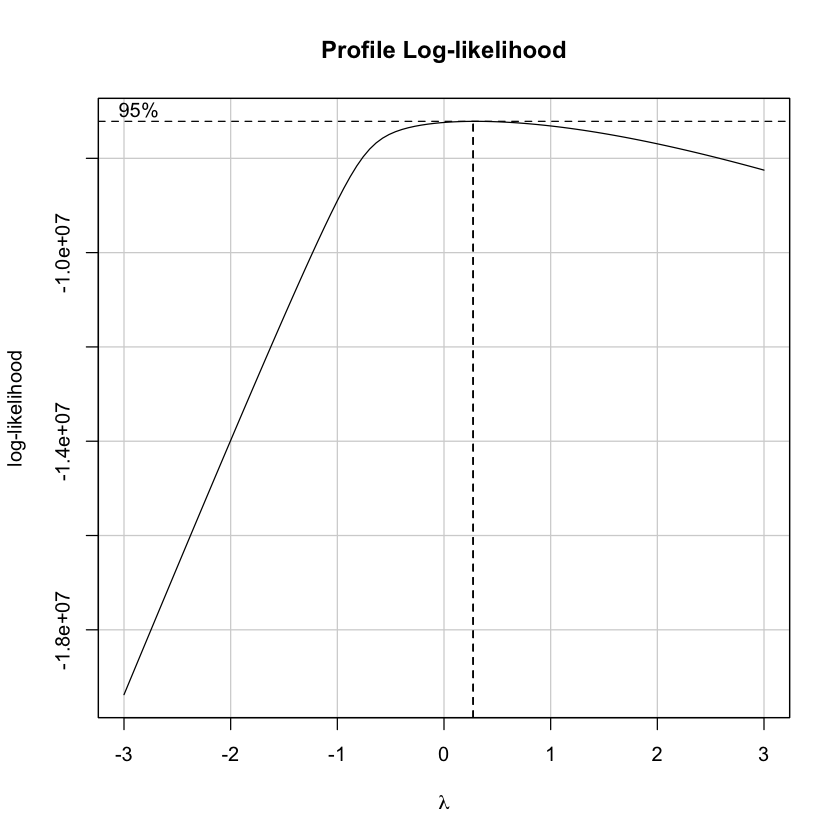

In [34]:
# Apply Box-Cox transformation to find the optimal lambda
bc <- boxCox(price_elasticity_model_2, lambda = seq(-3, 3, by = 0.1))

opt_lambda <- bc$x[which.max(bc$y)]

# Round the optimal lambda to the nearest 0.5
opt_lambda_rounded <- round(opt_lambda / 0.5) * 0.5

cat("Optimal lambda:", opt_lambda_rounded, "\n")

In [109]:
# Apply the square root transformation to ORDER_TOTAL_AMOUNT
df$sqrt_order_total <- sqrt(df$ORDER_TOTAL_AMOUNT)

Warning message:
“Removed 635 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


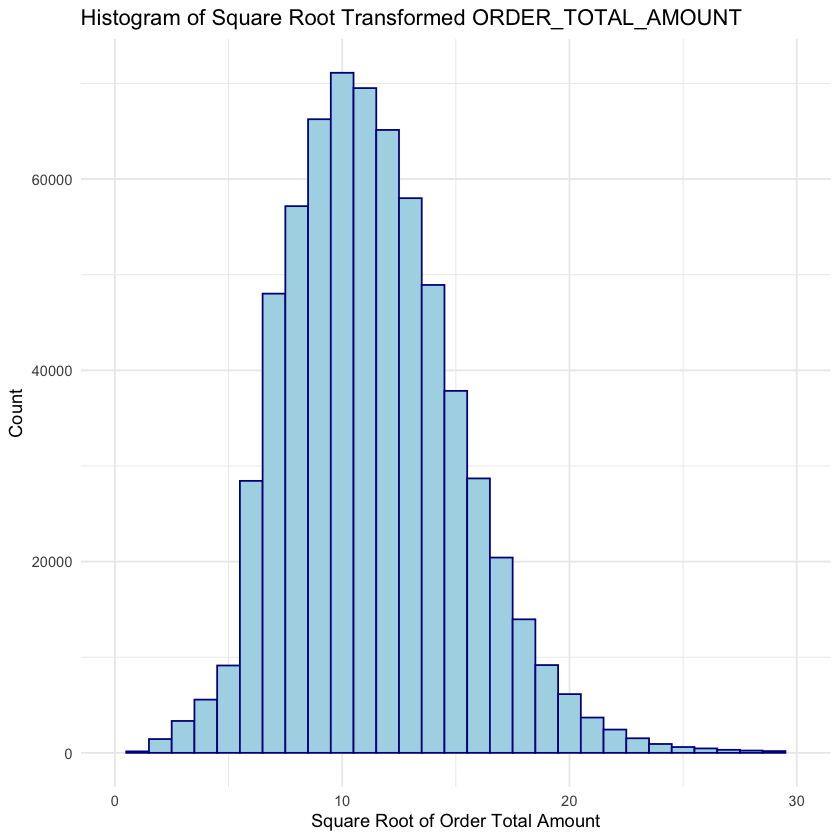

In [110]:
# Histogram of the square root-transformed variable
ggplot(df, aes(x = sqrt_order_total)) +
  geom_histogram(binwidth = 1, fill = "lightblue", color = "darkblue") +
  scale_x_continuous(limits = c(0, 30)) +
  labs(
    title = "Histogram of Square Root Transformed ORDER_TOTAL_AMOUNT",
    x = "Square Root of Order Total Amount",
    y = "Count"
  ) +
  theme_minimal()

In [111]:
# Fit a new model using the transformed target variable
price_elasticity_model_transformed <- lm(sqrt_order_total ~ ITEM_PRICE + USER_INCOME_CLASS + ORDER_YEAR + 
                                           ORDER_MONTH + ORDER_QUARTER + SALES_PER_ITEM + USER_AGE_BAND
                                         + USER_AGE_BAND,
                                         data = df)

summary(price_elasticity_model_transformed)


Call:
lm(formula = sqrt_order_total ~ ITEM_PRICE + USER_INCOME_CLASS + 
    ORDER_YEAR + ORDER_MONTH + ORDER_QUARTER + SALES_PER_ITEM + 
    USER_AGE_BAND + USER_AGE_BAND, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-26.861  -2.674  -0.316   2.303 149.894 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 2.682e+02  6.490e+00  41.335  < 2e-16 ***
ITEM_PRICE                 -1.078e-02  1.094e-03  -9.860  < 2e-16 ***
USER_INCOME_CLASS0-25k     -4.422e-01  3.247e-02 -13.617  < 2e-16 ***
USER_INCOME_CLASS100k-150k  3.481e-02  2.840e-02   1.226   0.2204    
USER_INCOME_CLASS150k-200k  1.230e-01  3.074e-02   4.000 6.33e-05 ***
USER_INCOME_CLASS200k+      4.440e-01  2.999e-02  14.804  < 2e-16 ***
USER_INCOME_CLASS25k-50k   -3.704e-01  2.975e-02 -12.452  < 2e-16 ***
USER_INCOME_CLASS50k-75k   -1.991e-01  2.880e-02  -6.913 4.76e-12 ***
USER_INCOME_CLASS75k-100k  -1.692e-01  2.879e-02  -5.876 4.19e-09 ***
ORDER_Y

# Experiment 3

Will continue with the same dataframe from experiment 2.

In [64]:
# Train the decision tree model using the training set
tree_model_1 <- rpart(ORDER_TOTAL_AMOUNT ~ ITEM_PRICE + USER_INCOME_CLASS + ORDER_YEAR + 
                                           ORDER_MONTH + ORDER_QUARTER + SALES_PER_ITEM + USER_AGE_BAND +
                                           USER_GENDER,
                    data = df,
                    method = "anova",
                    control = rpart.control(cp = 0.001, maxdepth = 5, minsplit = 20))

# Disable scientific notation globally
options(scipen = 999)

In [54]:
# Modify the function to directly control label formatting
custom_rpart_plot <- function(model) {
  # Manually format the node labels to prevent scientific notation
  formatted_tree <- rpart.plot(model, 
                               digits = -1,   # Increase precision
                               varlen = 0,   # Ensure full variable names
                               tweak = 1.1,  # Adjust label sizes for better clarity
                               box.palette = "Blues")  # Optional: make the plot visually clear
  return(formatted_tree)
}

$obj
n= 653687 

node), split, n, deviance, yval
      * denotes terminal node

 1) root 653687 5312096000 142.7935  
   2) SALES_PER_ITEM< 7.005 428698 3111208000 137.6896  
     4) ORDER_YEAR>=2021.5 137153  998931300 125.7229  
       8) USER_INCOME_CLASS=,0-25k,25k-50k,50k-75k,75k-100k 79351  535168900 120.0748 *
       9) USER_INCOME_CLASS=100k-150k,150k-200k,200k+ 57802  457756100 133.4766 *
     5) ORDER_YEAR< 2021.5 291545 2083396000 143.3192  
      10) USER_AGE_BAND=,18-20,21-24,25-34,55-64,65+ 162116 1109575000 137.6149 *
      11) USER_AGE_BAND=35-44,45-54 129429  961938300 150.4641 *
   3) SALES_PER_ITEM>=7.005 224989 2168443000 152.5185  
     6) USER_INCOME_CLASS=,0-25k,100k-150k,25k-50k,50k-75k,75k-100k 168490 1554507000 148.2602  
      12) USER_AGE_BAND=18-20,21-24,25-34,55-64,65+ 76609  661746100 141.9546 *
      13) USER_AGE_BAND=,35-44,45-54 91881  887174800 153.5178 *
     7) USER_INCOME_CLASS=150k-200k,200k+ 56499  601769900 165.2172 *

$snipped.nodes
NULL

$xlim

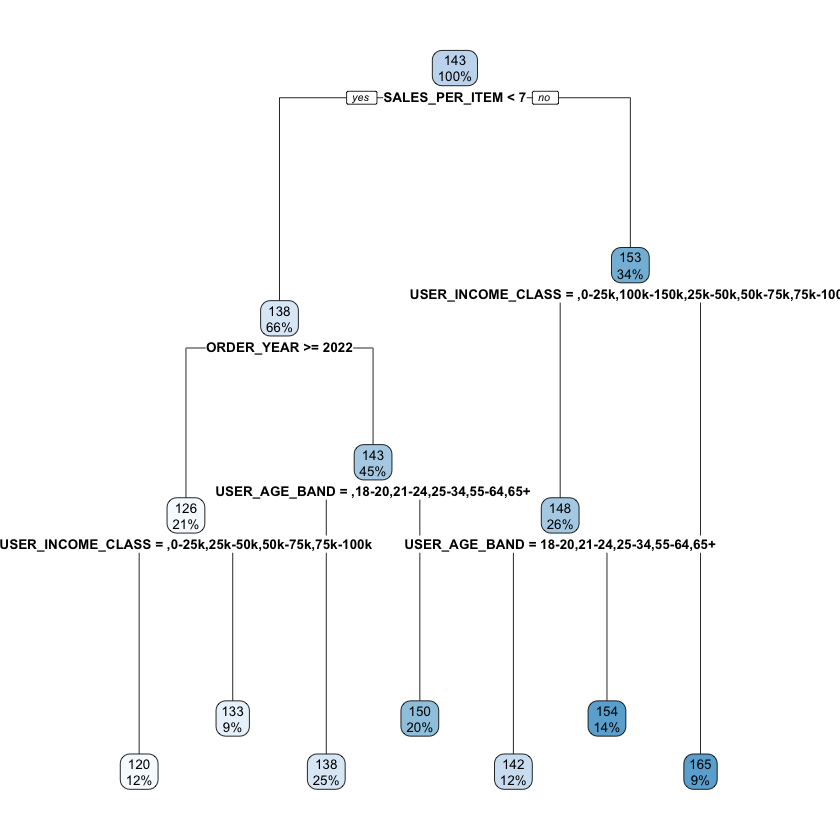

In [65]:
custom_rpart_plot(tree_model_1)

In [68]:
test_data <- test_data %>% filter(ITEM_PRICE > 0 & ORDER_TOTAL_AMOUNT > 0)

test_data <- test_data %>% filter(!is.na(ORDER_TOTAL_AMOUNT))

test_data <- test_data %>% filter(ORDER_TOTAL_AMOUNT < quantile(ORDER_TOTAL_AMOUNT, 0.99))

In [69]:
# Generate predictions using the decision tree model
predictions <- predict(tree_model_1, newdata = test_data)

# Calculate MAE
mae <- mean(abs(predictions - test_data$ORDER_TOTAL_AMOUNT))
print(paste("Mean Absolute Error (MAE):", mae))

# Calculate RMSE
rmse <- sqrt(mean((predictions - test_data$ORDER_TOTAL_AMOUNT)^2))
print(paste("Root Mean Squared Error (RMSE):", rmse))

[1] "Mean Absolute Error (MAE): 69.1328119151029"
[1] "Root Mean Squared Error (RMSE): 89.0152498268218"


# Experiment 4

In [85]:
#Reset df
df <- train_data

In [86]:
df <- df %>% filter(!is.na(ORDER_TOTAL_QUANTITY))
df <- df %>% filter(ORDER_TOTAL_QUANTITY < quantile(ORDER_TOTAL_QUANTITY, 0.99))

In [87]:
# Create a new variable for average price per unit
df$AVG_PRICE_PER_UNIT <- df$ORDER_TOTAL_AMOUNT / df$ORDER_TOTAL_QUANTITY

In [94]:
df <- df %>% filter(AVG_PRICE_PER_UNIT > 0 & ORDER_TOTAL_QUANTITY > 0)

correlation <- cor(df$AVG_PRICE_PER_UNIT, df$ORDER_TOTAL_QUANTITY, use = "complete.obs")
correlation

[1] -0.3723052

In [113]:
summary(df$ORDER_TOTAL_QUANTITY)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   14.00   26.00   31.62   44.00  118.00 

In [95]:
# Create log-transformed columns
df$log_quantity <- log(df$ORDER_TOTAL_QUANTITY + 1)
df$log_avg_price <- log(df$AVG_PRICE_PER_UNIT + 1)

In [99]:
options(scipen = 0)  

In [114]:
price_elasticity_model_3 <- lm(log_quantity ~ log_avg_price + USER_INCOME_CLASS , 
                                  data = df)

# Print the summary of the simplified model
cat("\n--- Price Elasticity Model Summary ---\n")
summary(price_elasticity_model_3)


--- Price Elasticity Model Summary ---



Call:
lm(formula = log_quantity ~ log_avg_price + USER_INCOME_CLASS, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.0426 -0.4093  0.0421  0.4508  4.6892 

Coefficients:
                            Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                 4.796816   0.004154 1154.773   <2e-16 ***
log_avg_price              -0.881912   0.001499 -588.377   <2e-16 ***
USER_INCOME_CLASS0-25k     -0.053508   0.004318  -12.392   <2e-16 ***
USER_INCOME_CLASS100k-150k  0.037032   0.003569   10.375   <2e-16 ***
USER_INCOME_CLASS150k-200k  0.040758   0.004044   10.079   <2e-16 ***
USER_INCOME_CLASS200k+      0.074038   0.003855   19.206   <2e-16 ***
USER_INCOME_CLASS25k-50k   -0.039820   0.003836  -10.380   <2e-16 ***
USER_INCOME_CLASS50k-75k   -0.002256   0.003685   -0.612   0.5404    
USER_INCOME_CLASS75k-100k   0.006785   0.003692    1.838   0.0661 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6336 on 65

In [102]:
test_data <- test_data %>% filter(!is.na(ORDER_TOTAL_QUANTITY))
test_data <- test_data %>% filter(ORDER_TOTAL_QUANTITY < quantile(ORDER_TOTAL_QUANTITY, 0.99))

In [103]:
# Create a new variable for average price per unit
test_data$AVG_PRICE_PER_UNIT <- test_data$ORDER_TOTAL_AMOUNT / test_data$ORDER_TOTAL_QUANTITY

In [104]:
test_data <- test_data %>% filter(AVG_PRICE_PER_UNIT > 0 & ORDER_TOTAL_QUANTITY > 0)

In [105]:
test_data$log_quantity <- log(test_data$ORDER_TOTAL_QUANTITY + 1)  
test_data$log_avg_price <- log(test_data$AVG_PRICE_PER_UNIT + 1)   

In [106]:
predictions_log_quantity <- predict(price_elasticity_model_3, newdata = test_data)

In [107]:
# Back-transform predictions to the original scale
predictions_original_scale <- exp(predictions_log_quantity) - 1 

# Calculate evaluation metrics
mae <- mean(abs(predictions_original_scale - test_data$ORDER_TOTAL_QUANTITY))
rmse <- sqrt(mean((predictions_original_scale - test_data$ORDER_TOTAL_QUANTITY)^2))

# Print the results
cat("Mean Absolute Error (MAE):", mae, "\n")
cat("Root Mean Squared Error (RMSE):", rmse, "\n")

Mean Absolute Error (MAE): 14.32398 
Root Mean Squared Error (RMSE): 19.99888 
